# Домашнее задание: Multi-Branch MLP для Wine Quality

**Цель**: Реализовать multi-branch модель и добиться F1 score ≥ 40%

**Задачи**:
1. Реализовать три типа блоков: Bottleneck, Inverted Bottleneck, Regular
2. Создать Multi-Branch архитектуру
3. Использовать weighted loss для борьбы с дисбалансом классов
4. Подобрать оптимальные гиперпараметры (глубина, ширина, lr, оптимизатор)

In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.utils.class_weight import compute_class_weight
import sys
sys.path.append('/content/lesson3/seminar')
from wine_quality_data import WineQualityDataModule
from lightning_module import BaseLightningModule
from utils import set_seed
from pytorch_lightning import Trainer

sns.set_style('whitegrid')
set_seed(42)

## 1. Загрузка и анализ данных

Загрузим Wine Quality датасет и проанализируем распределение классов.

In [ ]:
# Загружаем данные
dm = WineQualityDataModule(batch_size=128)
dm.setup()

print(f'Train samples: {len(dm.train_dataset)}')
print(f'Val samples: {len(dm.val_dataset)}')
print(f'Input dim: {dm.input_dim}')
print(f'Num classes: {dm.n_classes}')

Train samples: 1279
Val samples: 320
Input dim: 11
Num classes: 6


### 1.1. Анализ дисбаланса классов

Проанализируйте распределение классов и вычислите веса для weighted loss.

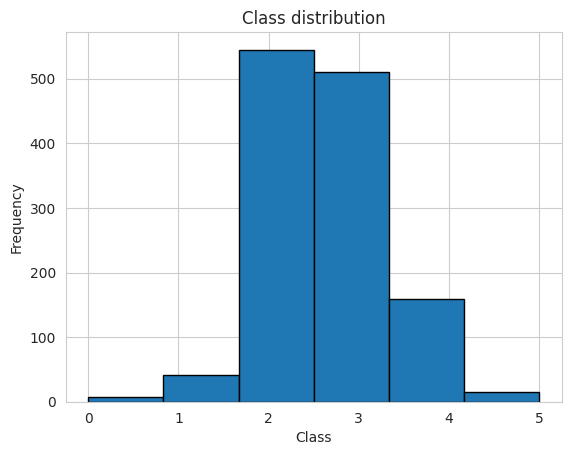

Class weights: [26.64583333  5.07539683  0.3911315   0.41797386  1.34067086 14.21111111]


In [ ]:
# Получаем метки классов из train_dataset
train_labels = [dm.train_dataset[i][1] for i in range(len(dm.train_dataset))]

# Преобразуем в numpy array и убеждаемся, что это целые числа
train_labels = np.array(train_labels, dtype=np.int64)

# Строим гистограмму распределения классов
import matplotlib.pyplot as plt
plt.hist(train_labels, bins=len(set(train_labels)), edgecolor='black')
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()

# Вычисляем веса классов
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Убедимся, что classes — это все возможные метки (0, 1, ..., n_classes-1)
classes = np.arange(dm.n_classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_labels
)
print(f'Class weights: {class_weights}')


## 2. Реализация блоков

Реализуйте три типа блоков:
- **Bottleneck**: dim → dim//4 → dim (сужение)
- **Inverted Bottleneck**: dim → dim*4 → dim (расширение)
- **Regular**: dim → hidden_dim → dim (обычный)

In [ ]:
from abc import ABC, abstractmethod

class BaseMLPBlock(nn.Module, ABC):
    """Базовый класс для MLP блока"""
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__()
        self.dim = dim
        self.activation = {'relu': nn.ReLU(), 'gelu': nn.GELU(), 'swish': nn.SiLU()}.get(activation, nn.GELU())
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None

    @abstractmethod
    def forward(self, x):
        pass

class BottleneckBlock(BaseMLPBlock):
    """
    Bottleneck блок: dim → dim//4 → dim

    Сужает размерность в 4 раза, затем восстанавливает.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)

        # Bottleneck dimension (сужение в 4 раза)
        self.bottleneck_dim = max(dim // 4, 1)

        # Линейные слои: dim → bottleneck_dim → dim
        self.fc1 = nn.Linear(self.dim, self.bottleneck_dim)
        self.fc2 = nn.Linear(self.bottleneck_dim, self.dim)

    def forward(self, x):
        identity = x

        # Bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)

        # Residual connection
        return out + identity

class InvertedBottleneckBlock(BaseMLPBlock):
    """
    Inverted Bottleneck блок: dim → dim*4 → dim

    Расширяет размерность в 4 раза, затем сжимает обратно.
    Использует residual connection для стабильного обучения.
    """
    def __init__(self, dim, expansion_factor=4, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)

        # Expanded dimension (расширение в 4 раза)
        self.expanded_dim = dim * expansion_factor

        # Линейные слои: dim → expanded_dim → dim
        self.fc1 = nn.Linear(self.dim, self.expanded_dim)
        self.fc2 = nn.Linear(self.expanded_dim, self.dim)

    def forward(self, x):
        identity = x

        # Inverted bottleneck pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)

        # Residual connection
        return out + identity

class RegularBlock(BaseMLPBlock):
    """
    Regular блок: dim → hidden_dim → dim

    Обычный двухслойный MLP с residual connection.
    hidden_dim по умолчанию равен dim * 2.
    """
    def __init__(self, dim, hidden_dim=None, activation='gelu', dropout=0.0):
        super().__init__(dim, activation, dropout)

        # Hidden dimension (по умолчанию в 2 раза больше)
        self.hidden_dim = hidden_dim if hidden_dim else dim * 2

        # Линейные слои: dim → hidden_dim → dim
        self.fc1 = nn.Linear(self.dim, self.hidden_dim)
        self.fc2 = nn.Linear(self.hidden_dim, self.dim)

    def forward(self, x):
        identity = x

        # Regular pathway
        out = self.fc1(x)
        out = self.activation(out)
        if self.dropout:
            out = self.dropout(out)
        out = self.fc2(out)

        # Residual connection
        return out + identity

# Тестируем блоки
print('✓ Блоки успешно определены!')
print()

# Проверим размерности
test_x = torch.randn(4, 64)
print('Тестирование блоков с размерностью 64:')
print(f'  Input shape: {test_x.shape}')

bottleneck = BottleneckBlock(64)
print(f'  BottleneckBlock output: {bottleneck(test_x).shape}')

inverted = InvertedBottleneckBlock(64)
print(f'  InvertedBottleneckBlock output: {inverted(test_x).shape}')

regular = RegularBlock(64)
print(f'  RegularBlock output: {regular(test_x).shape}')

# Подсчитаем параметры
print()
print('Количество параметров:')
print(f'  BottleneckBlock: {sum(p.numel() for p in bottleneck.parameters()):,}')
print(f'  InvertedBottleneckBlock: {sum(p.numel() for p in inverted.parameters()):,}')
print(f'  RegularBlock: {sum(p.numel() for p in regular.parameters()):,}')

✓ Блоки успешно определены!

Тестирование блоков с размерностью 64:
  Input shape: torch.Size([4, 64])
  BottleneckBlock output: torch.Size([4, 64])
  InvertedBottleneckBlock output: torch.Size([4, 64])
  RegularBlock output: torch.Size([4, 64])

Количество параметров:
  BottleneckBlock: 2,128
  InvertedBottleneckBlock: 33,088
  RegularBlock: 16,576


## 3. Multi-Branch модель

Реализуйте модель с тремя параллельными ветками.

**Архитектура**:
```
         Input
           |
      projection
           |
      ┌────┼────┐
      │    │    │
  Bottleneck  Inverted  Regular
   Branch      Branch    Branch
      │    │    │
      └────┼────┘
           |
      Concatenate/Sum
           |
      projection
           |
        Output
```

In [ ]:
class MultiBranchMLP(nn.Module):
    """Multi-Branch MLP с тремя параллельными ветками.

    Args:
        input_dim: размерность входа
        hidden_dim: размерность скрытых слоев
        output_dim: размерность выхода (число классов)
        num_blocks: количество блоков в каждой ветке
        dropout: вероятность dropout
        combine_mode: способ объединения веток ('concat' или 'sum')
    """
    def __init__(
        self,
        input_dim,
        hidden_dim,
        output_dim,
        num_blocks=4,
        dropout=0.1,
        combine_mode='concat'
    ):
        super().__init__()
        self.output_dim = output_dim
        self.combine_mode = combine_mode

        # Входная проекция
        self.input_proj = nn.Linear(input_dim, hidden_dim)

        # Создайте три ветки (branches)
        # Branch 1: num_blocks блоков BottleneckBlock
        # Branch 2: num_blocks блоков InvertedBottleneckBlock
        # Branch 3: num_blocks блоков RegularBlock
        # Используйте nn.ModuleList
        self.bottleneck_branch = nn.ModuleList(
            [BottleneckBlock(hidden_dim) for _ in range(num_blocks)]
        )
        self.inverted_branch = nn.ModuleList(
            [InvertedBottleneckBlock(hidden_dim) for _ in range(num_blocks)]
        )
        self.regular_branch = nn.ModuleList(
            [RegularBlock(hidden_dim) for _ in range(num_blocks)]
        )

        # Выходная проекция
        # Если combine_mode == 'concat', то вход будет hidden_dim * 3
        # Если combine_mode == 'sum', то вход будет hidden_dim
        if combine_mode == 'concat':
            self.output_proj = nn.Linear(hidden_dim * 3, output_dim)
        else:  # sum
            self.output_proj = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # 1. Входная проекция
        x_proj = self.input_proj(x)

        # 2. Пропустите через каждую ветку
        # Bottleneck branch
        for block in self.bottleneck_branch:
            x_proj = block(x_proj)

        # Inverted branch (начинаем с input_proj)
        x_inverted = self.input_proj(x)
        for block in self.inverted_branch:
            x_inverted = block(x_inverted)

        # Regular branch (начинаем с input_proj)
        x_regular = self.input_proj(x)
        for block in self.regular_branch:
            x_regular = block(x_regular)

        # 3. Объедините результаты (concat или sum)
        if self.combine_mode == 'concat':
            combined = torch.cat([x_proj, x_inverted, x_regular], dim=1)
        else:  # sum
            combined = x_proj + x_inverted + x_regular

        # 4. Выходная проекция
        out = self.output_proj(combined)
        return out

print('Multi-Branch модель определена!')


Multi-Branch модель определена!


## 4. Код обучение

In [ ]:
from pytorch_lightning.callbacks import EarlyStopping

def train_model(
    model,
    dm,
    class_weights=None,
    max_epochs=50,
    lr=1e-3,
    optimizer_type='adam'
):
    """Обучает модель с weighted loss.

    Args:
        model: модель для обучения
        dm: DataModule
        class_weights: веса классов для weighted loss (numpy array или None)
        max_epochs: количество эпох
        lr: learning rate
        optimizer_type: тип оптимизатора ('adam', 'adamw', 'sgd')

    Returns:
        dict с метриками
    """
    # Создайте loss function
    # Если class_weights не None, используйте nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    # Иначе используйте обычный nn.CrossEntropyLoss()
    if class_weights is not None:
        loss_fn = nn.CrossEntropyLoss(weight=torch.FloatTensor(class_weights))
    else:
        loss_fn = nn.CrossEntropyLoss()

    lightning_model = BaseLightningModule(
        model=model,
        loss_fn=loss_fn,
        optimizer_type=optimizer_type,
        learning_rate=lr,
        task_type='multiclass'
    )

    # Early stopping по val_loss
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        mode='min',
        verbose=False
    )

    trainer = Trainer(
        max_epochs=max_epochs,
        enable_checkpointing=False,
        logger=False,
        enable_progress_bar=True,
        enable_model_summary=False,
        callbacks=[early_stop]
    )
    trainer.fit(lightning_model, dm)

    metrics = trainer.callback_metrics
    return {
        'val_acc': metrics.get('val_accuracy', 0).item(),
        'val_f1': metrics.get('val_f1_macro', 0).item()
    }


## 5. Итоговая модель

Обучите модель с лучшими гиперпараметрами.

In [ ]:
# Убедимся, что class_weights уже определены
assert 'class_weights' in globals(), "Выполните сначала ячейку с вычислением class_weights!"

# Списки значений для перебора
depths = [2, 4]          # сначала попробуем меньше, чтобы быстро увидеть результат
widths = [64, 128]
lrs = [1e-3, 1e-4]
optimizers = ['adam', 'adamw']

best_f1 = 0.0
best_config = {}

for num_blocks in depths:
    for hidden_dim in widths:
        for lr in lrs:
            for opt in optimizers:
                print(f"Testing: depth={num_blocks}, width={hidden_dim}, lr={lr}, optimizer={opt}")

                model = MultiBranchMLP(
                    input_dim=dm.input_dim,
                    hidden_dim=hidden_dim,
                    output_dim=dm.n_classes,
                    num_blocks=num_blocks,
                    dropout=0.1,
                    combine_mode='concat'
                )

                # Уменьшаем max_epochs для быстрого теста
                results = train_model(
                    model=model,
                    dm=dm,
                    class_weights=class_weights,
                    max_epochs=20,           # 20 эпох — достаточно для теста
                    lr=lr,
                    optimizer_type=opt
                )

                print(f"  Val F1: {results['val_f1']:.4f}, Val Acc: {results['val_acc']:.4f}")

                if results['val_f1'] > best_f1:
                    best_f1 = results['val_f1']
                    best_config = {
                        'num_blocks': num_blocks,
                        'hidden_dim': hidden_dim,
                        'lr': lr,
                        'optimizer': opt,
                        'val_acc': results['val_acc'],
                        'val_f1': results['val_f1']
                    }

print("\nBest config:")
print(best_config)

# Лучшие параметры
best_depth = best_config['num_blocks']
best_hidden_dim = best_config['hidden_dim']
best_lr = best_config['lr']
best_optimizer = best_config['optimizer']

# Итоговая модель
final_model = MultiBranchMLP(
    input_dim=dm.input_dim,
    hidden_dim=best_hidden_dim,
    output_dim=dm.n_classes,
    num_blocks=best_depth,
    dropout=0.1,
    combine_mode='concat'
)

# Обучение на 100 эпох, но с явным max_epochs и без early stopping
final_results = train_model(
    final_model,
    dm,
    class_weights=class_weights,
    max_epochs=100,
    lr=best_lr,
    optimizer_type=best_optimizer
)

print(f"\n=== Итоговые результаты ===")
print(f"F1 score: {final_results['val_f1']:.4f}")
print(f"Accuracy: {final_results['val_acc']:.4f}")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Output()

Epoch 0: accuracy=0.1133, f1_macro=0.0871

Testing: depth=2, width=64, lr=0.001, optimizer=adam


Epoch 0: accuracy=0.1875, f1_macro=0.1225

...

Epoch 9: accuracy=0.3785, f1_macro=0.2384

Epoch 10: accuracy=0.3808, f1_macro=0.2388

Epoch 11: accuracy=0.3889, f1_macro=0.2423

Epoch 12: accuracy=0.3881, f1_macro=0.2427


=== Итоговые результаты ===
F1 score: 0.2427
Accuracy: 0.3881
